In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "datasets"

# Car Insurance Claim Prediction: An Actuarial Statistics Approach

## Executive Summary
Analysis of 58,592 motor policy records to identify and quantify the factors driving claim occurrence. This project applies actuarial statistical methods — probability modelling, hypothesis testing, regression, GLMs, and Bayesian credibility theory — to assess and price motor insurance risk.

## Business Objective
Build a statistical framework to estimate the probability of a policyholder making a claim, and to identify which vehicle, policyholder, and regional characteristics are the strongest risk indicators. This mirrors the underwriting and pricing questions an actuary addresses when segmenting a motor book.

## Dataset Overview
- **Records:** 58,592 policies
- **Target Variable:** `is_claim` (binary: claim / no claim in the policy period)
- **Key Features:** policyholder age, vehicle age, population density of area, vehicle segment, safety features (airbags, NCAP rating, ESC), engine specifications

## Key Findings
*(fill in after running — e.g. overall claim rate, most significant predictors, p-values)*
- Overall claim rate: **[X]%**
- Strongest predictor(s) from the GLM: **[X]**

## Technical Skills Applied
- **Language:** R programming (base R + tidyverse)
- **Statistical Methods:** Probability distributions, hypothesis testing (t-test, F-test), ANOVA, correlation, linear regression, generalized linear models (logistic), Bayesian credibility theory
- **Tools:** Base R, data aggregation, model fitting, data visualization

## Actuarial Relevance
This project demonstrates CS1-level actuarial competencies:
- Probability and distribution theory applied to claim frequency
- Statistical inference and significance testing
- Regression and GLM-based risk modelling
- Bayesian/credibility methods for risk segmentation (as used in experience rating)

## Conclusion
*(summarised at the end of the notebook once results are in)*

---
**Knowledge Level:** CS1 (Actuarial Statistics)
**Relevant Exams:** CM1, CS1

## 1. Data Structures & Exploration
Loading the dataset and examining its structure — vectors, matrices, and data frames.

In [2]:
list.files("../input")
list.files("../input/datasets")
list.files(path="../input/datasets")
list.files(path="../input/datasets/ifteshanajnin")
list.files(path="../input/datasets/ifteshanajnin/carinsuranceclaimprediction-classification")
insurance_claim <- read.csv("../input/datasets/ifteshanajnin/carinsuranceclaimprediction-classification/train.csv")
head(insurance_claim)
tail(insurance_claim)
str(insurance_claim)
dim(insurance_claim)
summary(insurance_claim)
insurance_claim <- read.csv("../input/datasets/ifteshanajnin/carinsuranceclaimprediction-classification/train.csv")


# Convert key variables to factors for analysis
insurance_claim$is_claim   <- factor(insurance_claim$is_claim, levels = c(0,1), labels = c("No Claim","Claim"))
insurance_claim$segment    <- as.factor(insurance_claim$segment)
insurance_claim$fuel_type  <- as.factor(insurance_claim$fuel_type)
insurance_claim$area_cluster <- as.factor(insurance_claim$area_cluster)

levels(insurance_claim$is_claim)
table(insurance_claim$is_claim)

# Base R matrix demo — numeric snapshot of the first 5 policies
policy_matrix <- as.matrix(insurance_claim[1:5, c("age_of_car","age_of_policyholder","population_density","ncap_rating")])
policy_matrix

[1] "datasets"

[1] "ifteshanajnin"

[1] "ifteshanajnin"

[1] "carinsuranceclaimprediction-classification"

[1] "sample_submission.csv" "test.csv"              "train.csv"

...

[1] 58592    44

  policy_id         policy_tenure        age_of_car      age_of_policyholder
 Length:58592       Min.   :0.002735   Min.   :0.00000   Min.   :0.2885     
 Class :character   1st Qu.:0.210250   1st Qu.:0.02000   1st Qu.:0.3654     
 Mode  :character   Median :0.573792   Median :0.06000   Median :0.4519     
                    Mean   :0.611246   Mean   :0.06942   Mean   :0.4694     
                    3rd Qu.:1.039104   3rd Qu.:0.11000   3rd Qu.:0.5481     
                    Max.   :1.396641   Max.   :1.00000   Max.   :1.0000     
 area_cluster       population_density      make         segment         
 Length:58592       Min.   :  290      Min.   :1.000   Length:58592      
 Class :character   1st Qu.: 6112      1st Qu.:1.000   Class :character  
 Mode  :character   Median : 8794      Median :1.000   Mode  :character  
                    Mean   :18827      Mean   :1.764                     
                    3rd Qu.:27003      3rd Qu.:3.000                     
                 

[1] "No Claim" "Claim"


No Claim    Claim 
   54844     3748 

,age_of_car,age_of_policyholder,population_density,ncap_rating
1,0.05,0.6442308,4990,0
2,0.02,0.3750000,27003,0
3,0.02,0.3846154,4076,0
4,0.11,0.4326923,21622,2
5,0.11,0.6346154,34738,2


## 2. Descriptive Statistics
Summarising the central tendency and spread of key policyholder and vehicle variables.

In [3]:
summary(insurance_claim$age_of_policyholder)
summary(insurance_claim$population_density)

mean(insurance_claim$age_of_car)
median(insurance_claim$age_of_car)
var(insurance_claim$age_of_car)
sd(insurance_claim$age_of_car)
quantile(insurance_claim$age_of_car, probs = c(0.25, 0.5, 0.75, 0.95))

# Overall empirical claim rate
claim_rate <- mean(insurance_claim$is_claim == "Claim")
claim_rate

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2885  0.3654  0.4519  0.4694  0.5481  1.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    290    6112    8794   18827   27003   73430 

[1] 0.06942364

[1] 0.06

[1] 0.003217232

[1] 0.05672065

25%  50%  75%  95% 
0.02 0.06 0.11 0.17

[1] 0.06396778

## 3. Probability Distributions
Modelling the number of claims in a block of policies as a Binomial process, using the empirical claim rate as the probability parameter.

[1] 0.1158708

[1] 0.9016376

[1] 5

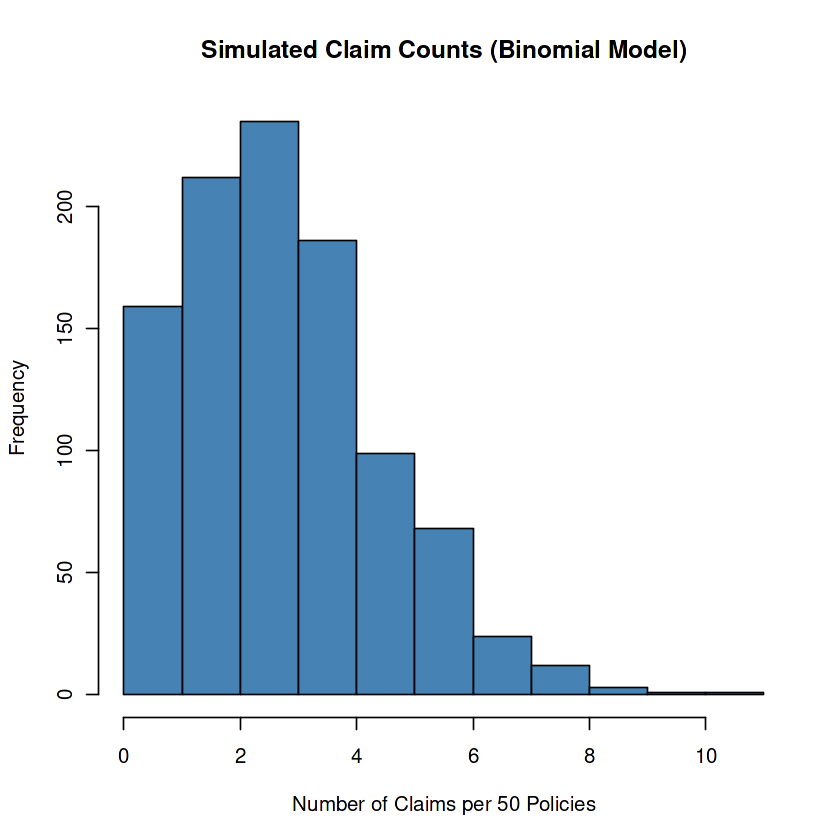

In [4]:
n_policies <- nrow(insurance_claim)
p_claim <- claim_rate

# Probability of exactly 5 claims in a sample of 50 policies
dbinom(x = 5, size = 50, prob = p_claim)

# Probability of at most 5 claims in 50 policies
pbinom(q = 5, size = 50, prob = p_claim)

# 90th percentile of claim count in a sample of 50 policies
qbinom(p = 0.9, size = 50, prob = p_claim)

# Simulate 1,000 blocks of 50 policies
set.seed(1)
simulated_claims <- rbinom(n = 1000, size = 50, prob = p_claim)

hist(simulated_claims, col = "steelblue",
     main = "Simulated Claim Counts (Binomial Model)",
     xlab = "Number of Claims per 50 Policies", ylab = "Frequency")

## 4. Statistical Inference & Hypothesis Testing
Testing whether policyholder age differs significantly between claimants and non-claimants.

In [5]:
age_claim    <- insurance_claim$age_of_policyholder[insurance_claim$is_claim == "Claim"]
age_no_claim <- insurance_claim$age_of_policyholder[insurance_claim$is_claim == "No Claim"]

t.test(age_claim, age_no_claim)
var.test(age_claim, age_no_claim)


	Welch Two Sample t-test

data:  age_claim and age_no_claim
t = 5.2998, df = 4245.4, p-value = 1.218e-07
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.007099026 0.015434787
sample estimates:
mean of x mean of y 
0.4799662 0.4686993 



	F test to compare two variances

data:  age_claim and age_no_claim
F = 1.0581, num df = 3747, denom df = 54843, p-value = 0.0168
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 1.010192 1.109332
sample estimates:
ratio of variances 
           1.05809 


## 5. Tabulation & ANOVA
Comparing claim frequency across vehicle segments, and testing whether population density varies significantly by segment.

         
          No Claim Claim
  A          16275  1046
  B1          3929   244
  B2         17058  1256
  C1          3329   228
  C2         13117   901
  Utility     1136    73

         
            No Claim      Claim
  A       0.93961088 0.06038912
  B1      0.94152888 0.05847112
  B2      0.93141859 0.06858141
  C1      0.93590104 0.06409896
  C2      0.93572550 0.06427450
  Utility 0.93961952 0.06038048

               Df    Sum Sq   Mean Sq F value Pr(>F)    
segment         5 1.973e+11 3.946e+10   127.9 <2e-16 ***
Residuals   58586 1.808e+13 3.085e+08                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

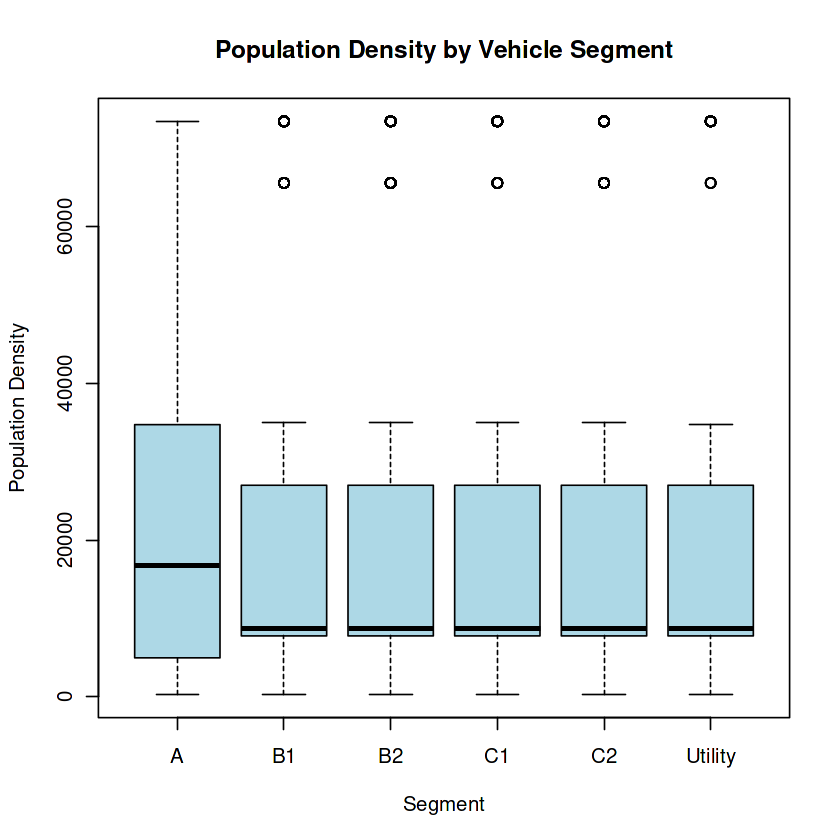

In [6]:
claim_table <- table(insurance_claim$segment, insurance_claim$is_claim)
claim_table
prop.table(claim_table, margin = 1)

density_anova <- aov(population_density ~ segment, data = insurance_claim)
summary(density_anova)

boxplot(population_density ~ segment, data = insurance_claim,
        col = "lightblue", main = "Population Density by Vehicle Segment",
        xlab = "Segment", ylab = "Population Density")

## 6. Correlation Analysis
Examining relationships between numeric vehicle and policyholder attributes.

In [7]:
numeric_vars <- insurance_claim[, c("age_of_car","age_of_policyholder","population_density",
                                     "gross_weight","turning_radius","ncap_rating")]
cor(numeric_vars)

cor.test(insurance_claim$age_of_car, insurance_claim$gross_weight)

,age_of_car,age_of_policyholder,population_density,gross_weight,turning_radius,ncap_rating
age_of_car,1.00000000,-0.035427172,-0.06225493,0.302126559,0.33271590,0.34885258
age_of_policyholder,-0.03542717,1.000000000,0.00966885,-0.007758234,-0.01676408,-0.03162770
population_density,-0.06225493,0.009668850,1.00000000,-0.077816338,-0.07750113,-0.07115023
gross_weight,0.30212656,-0.007758234,-0.07781634,1.000000000,0.82309676,0.55626990
turning_radius,0.33271590,-0.016764077,-0.07750113,0.823096759,1.00000000,0.77930173
ncap_rating,0.34885258,-0.031627703,-0.07115023,0.556269899,0.77930173,1.00000000



	Pearson's product-moment correlation

data:  insurance_claim$age_of_car and insurance_claim$gross_weight
t = 76.716, df = 58590, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2947505 0.3094666
sample estimates:
      cor 
0.3021266 


## 7. Multiple Linear Regression (MLR)
Fitted a Multiple Linear Regression (MLR) to assess how physical vehicle parameters (`turning_radius`, `displacement`, `age_of_car`) jointly impact the vehicle's `gross_weight`. Includes residual diagnostics to check the model's assumptions, and a prediction for a new vehicle spec.


Call:
lm(formula = gross_weight ~ turning_radius + displacement + age_of_car, 
    data = insurance_claim)

Residuals:
    Min      1Q  Median      3Q     Max 
-429.97  -26.53   14.60   72.70  321.69 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -1.614e+03  1.776e+01 -90.861   <2e-16 ***
turning_radius  5.726e+02  4.428e+00 129.310   <2e-16 ***
displacement    1.884e-01  3.890e-03  48.433   <2e-16 ***
age_of_car      1.766e+01  9.361e+00   1.886   0.0593 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 118.1 on 58588 degrees of freedom
Multiple R-squared:  0.6908,	Adjusted R-squared:  0.6908 
F-statistic: 4.362e+04 on 3 and 58588 DF,  p-value: < 2.2e-16


,2.5 %,97.5 %
(Intercept),-1648.6357558,-1579.0106885
turning_radius,563.9485007,581.3075962
displacement,0.1807625,0.1960099
age_of_car,-0.6921412,36.0025420


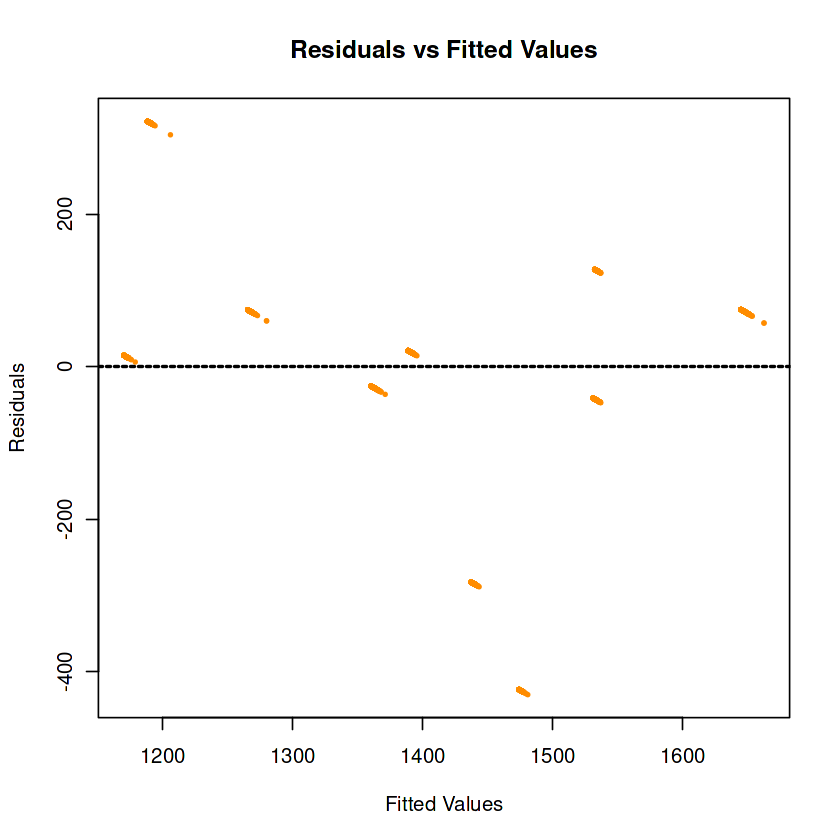

1 
1476.263

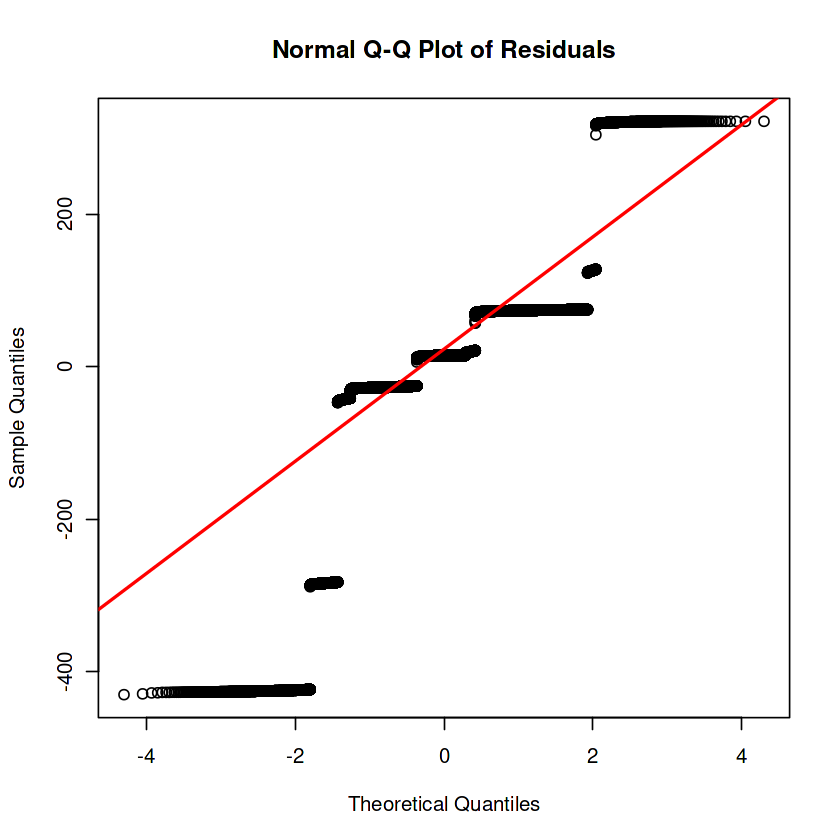

In [8]:
weight_mlr <- lm(gross_weight ~ turning_radius + displacement + age_of_car, 
                 data = insurance_claim)

summary(weight_mlr)
confint(weight_mlr)

mlr_residuals <- residuals(weight_mlr)
plot(fitted(weight_mlr), mlr_residuals,
     main = "Residuals vs Fitted Values", xlab = "Fitted Values", ylab = "Residuals",
     col = "darkorange", pch = 16, cex = 0.5)
abline(h = 0, col = "black", lwd = 2, lty = 2)

qqnorm(mlr_residuals, main = "Normal Q-Q Plot of Residuals")
qqline(mlr_residuals, col = "red", lwd = 2)

predict(weight_mlr, newdata = data.frame(turning_radius = 5, displacement = 1200, age_of_car = 0.05))

## 8. Generalized Linear Model (Logistic Regression)
Modelling claim probability directly using a binomial GLM — the standard actuarial approach for claim frequency modelling.


Call:
glm(formula = is_claim ~ age_of_car + age_of_policyholder + population_density + 
    ncap_rating + airbags, family = binomial, data = insurance_claim)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.864e+00  7.791e-02 -36.755  < 2e-16 ***
age_of_car          -2.605e+00  3.379e-01  -7.709 1.27e-14 ***
age_of_policyholder  7.085e-01  1.345e-01   5.268 1.38e-07 ***
population_density  -4.634e-06  1.017e-06  -4.555 5.24e-06 ***
ncap_rating          4.032e-02  1.348e-02   2.990  0.00279 ** 
airbags              9.756e-03  9.879e-03   0.988  0.32337    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 27860  on 58591  degrees of freedom
Residual deviance: 27749  on 58586  degrees of freedom
AIC: 27761

Number of Fisher Scoring iterations: 5


1          2          3          4          5          6 
0.07304058 0.05977609 0.06645512 0.05501867 0.05945713 0.07182839

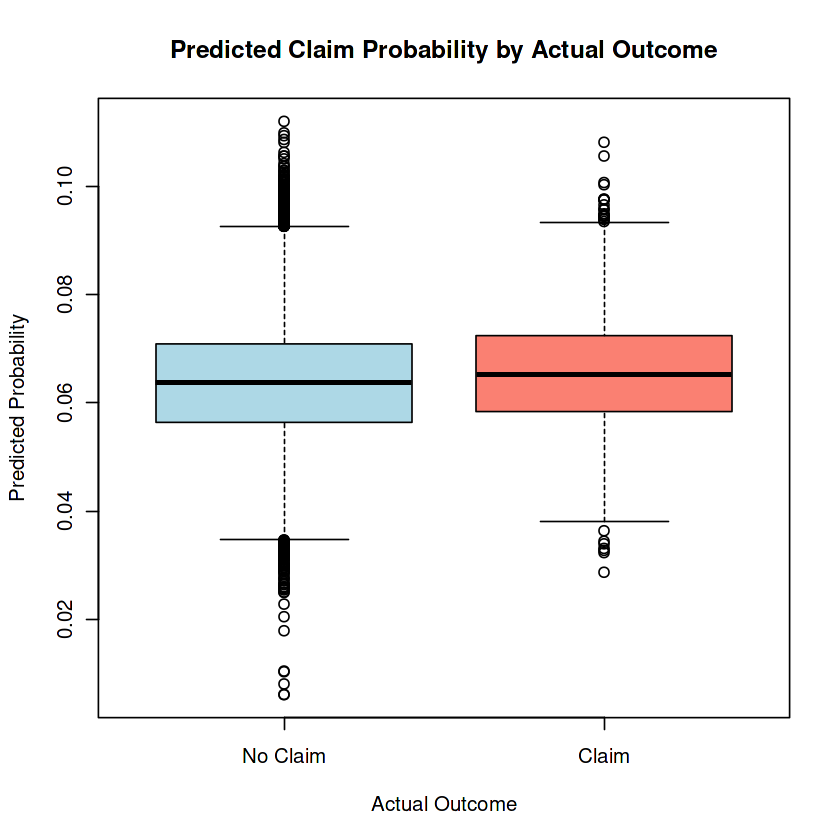

In [9]:
claim_glm <- glm(is_claim ~ age_of_car + age_of_policyholder + population_density +
                    ncap_rating + airbags,
                  data = insurance_claim, family = binomial)
summary(claim_glm)

predicted_prob <- predict(claim_glm, type = "response")
head(predicted_prob)

boxplot(predicted_prob ~ insurance_claim$is_claim, col = c("lightblue","salmon"),
        main = "Predicted Claim Probability by Actual Outcome",
        xlab = "Actual Outcome", ylab = "Predicted Probability")

## 9. Bayesian Credibility Theory (EBCT)
Using Empirical Bayes Credibility Theory to blend each vehicle segment's own claim experience (prior data) with the overall portfolio claim rate — shrinking noisy, low-volume segment estimates toward the collective mean.

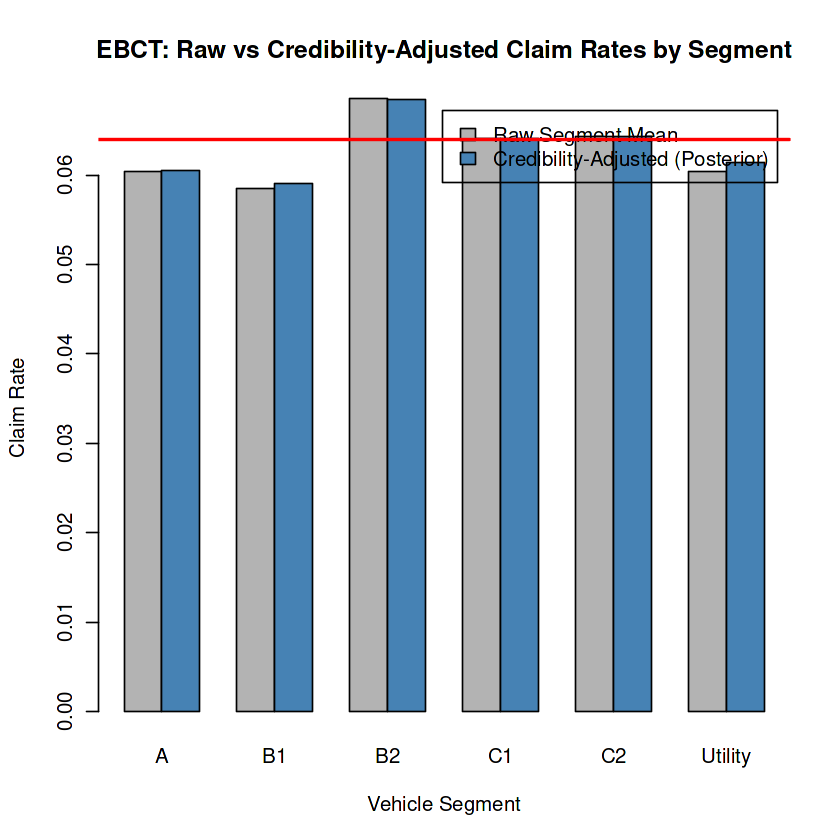

In [10]:
overall_claim_rate <- mean(insurance_claim$is_claim == "Claim")   # collective/prior mean

seg_mean <- tapply(insurance_claim$is_claim == "Claim", insurance_claim$segment, mean)
seg_n    <- table(insurance_claim$segment)

k <- 500   # credibility constant (higher k = less weight on own experience)
Z <- seg_n / (seg_n + k)
credibility_estimate <- Z * seg_mean + (1 - Z) * overall_claim_rate

comparison <- rbind(seg_mean, credibility_estimate)

barplot(comparison, beside = TRUE, col = c("gray70","steelblue"),
        legend.text = c("Raw Segment Mean", "Credibility-Adjusted (Posterior)"),
        main = "EBCT: Raw vs Credibility-Adjusted Claim Rates by Segment",
        xlab = "Vehicle Segment", ylab = "Claim Rate")
abline(h = overall_claim_rate, col = "red", lwd = 2)

## 10. Data Cleaning & Feature Engineering
`max_torque` and `max_power` are stored as text (e.g. "60Nm@3500rpm"). Extracting the numeric values so they can be used in statistical models — a routine step in real actuarial data prep.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   60.0    60.0   113.0   134.5   200.0   250.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  40.36   40.36   88.50   78.98   97.89  118.36 


	Pearson's product-moment correlation

data:  insurance_claim$torque_nm and insurance_claim$power_bhp
t = 494.76, df = 58590, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8966848 0.8998125
sample estimates:
    cor 
0.89826 


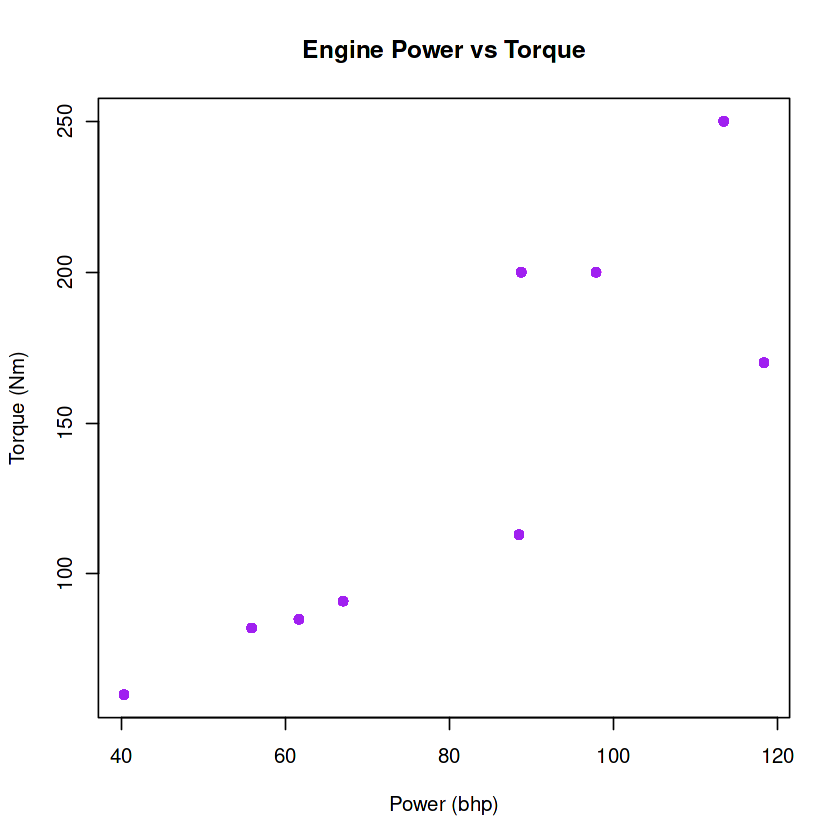

In [11]:
# Extract numeric torque (Nm) and power (bhp) from text columns
insurance_claim$torque_nm <- as.numeric(gsub("Nm.*", "", insurance_claim$max_torque))
insurance_claim$power_bhp <- as.numeric(gsub("bhp.*", "", insurance_claim$max_power))

summary(insurance_claim$torque_nm)
summary(insurance_claim$power_bhp)

cor.test(insurance_claim$torque_nm, insurance_claim$power_bhp)

plot(insurance_claim$power_bhp, insurance_claim$torque_nm,
     main = "Engine Power vs Torque", xlab = "Power (bhp)", ylab = "Torque (Nm)",
     col = "purple", pch = 16)

## 11. Chi-Square Test of Independence
Testing whether categorical vehicle attributes (fuel type, transmission type) are statistically associated with claim occurrence.

        
         No Claim Claim
  CNG       19095  1235
  Diesel    16580  1150
  Petrol    19169  1363


	Pearson's Chi-squared test

data:  fuel_claim_table
X-squared = 5.7596, df = 2, p-value = 0.05615


           
            No Claim Claim
  Automatic    19101  1310
  Manual       35743  2438


	Pearson's Chi-squared test with Yates' continuity correction

data:  transmission_claim_table
X-squared = 0.018648, df = 1, p-value = 0.8914


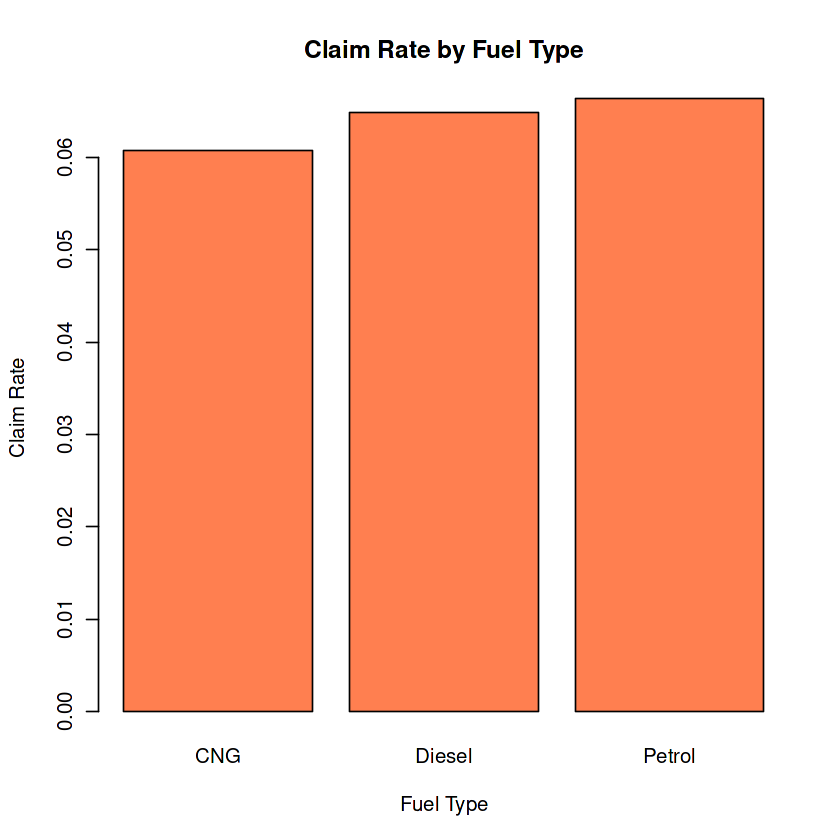

In [12]:
fuel_claim_table <- table(insurance_claim$fuel_type, insurance_claim$is_claim)
fuel_claim_table
chisq.test(fuel_claim_table)

transmission_claim_table <- table(insurance_claim$transmission_type, insurance_claim$is_claim)
transmission_claim_table
chisq.test(transmission_claim_table)

barplot(prop.table(fuel_claim_table, margin = 1)[, "Claim"],
        col = "coral", main = "Claim Rate by Fuel Type",
        xlab = "Fuel Type", ylab = "Claim Rate")

## 12. Confidence Intervals for Claim Proportions
Estimating a confidence interval around the overall claim rate, and comparing it across a safety-feature split — the kind of interval an actuary would quote alongside a point estimate.

In [13]:
# CI for overall claim proportion
prop.test(sum(insurance_claim$is_claim == "Claim"), nrow(insurance_claim))

# CI comparison: claim proportion for cars with vs without ESC
esc_yes <- insurance_claim$is_claim[insurance_claim$is_esc == "Yes"]
esc_no  <- insurance_claim$is_claim[insurance_claim$is_esc == "No"]

prop.test(x = c(sum(esc_yes == "Claim"), sum(esc_no == "Claim")),
          n = c(length(esc_yes), length(esc_no)))


	1-sample proportions test with continuity correction

data:  sum(insurance_claim$is_claim == "Claim") out of nrow(insurance_claim), null probability 0.5
X-squared = 44557, df = 1, p-value < 2.2e-16
alternative hypothesis: true p is not equal to 0.5
95 percent confidence interval:
 0.06200649 0.06598648
sample estimates:
         p 
0.06396778 



	2-sample test for equality of proportions with continuity correction

data:  c(sum(esc_yes == "Claim"), sum(esc_no == "Claim")) out of c(length(esc_yes), length(esc_no))
X-squared = 0.49948, df = 1, p-value = 0.4797
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.002747729  0.005905510
sample estimates:
    prop 1     prop 2 
0.06505081 0.06347192 


## 13. Multiple Logistic Regression with Interaction Terms
Extending the GLM from Section 8 with additional predictors (fuel type, engine power) and an interaction term, then formally comparing the two models via a deviance (ANOVA-style) test.

In [14]:
claim_glm_extended <- glm(is_claim ~ age_of_car + age_of_policyholder + population_density +
                             ncap_rating + airbags + fuel_type + power_bhp +
                             age_of_car:fuel_type,
                           data = insurance_claim, family = binomial)
summary(claim_glm_extended)

anova(claim_glm, claim_glm_extended, test = "Chisq")
AIC(claim_glm, claim_glm_extended)


Call:
glm(formula = is_claim ~ age_of_car + age_of_policyholder + population_density + 
    ncap_rating + airbags + fuel_type + power_bhp + age_of_car:fuel_type, 
    family = binomial, data = insurance_claim)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                -2.983e+00  1.239e-01 -24.079  < 2e-16 ***
age_of_car                 -5.560e+00  8.471e-01  -6.564 5.23e-11 ***
age_of_policyholder         6.734e-01  1.346e-01   5.002 5.66e-07 ***
population_density         -4.476e-06  1.019e-06  -4.394 1.11e-05 ***
ncap_rating                 6.030e-03  3.726e-02   0.162  0.87145    
airbags                    -1.365e-02  2.452e-02  -0.557  0.57768    
fuel_typeDiesel            -2.538e-01  1.868e-01  -1.359  0.17428    
fuel_typePetrol            -1.334e-01  1.246e-01  -1.071  0.28432    
power_bhp                   5.220e-03  2.833e-03   1.843  0.06533 .  
age_of_car:fuel_typeDiesel  3.259e+00  1.011e+00   3.225  0.00126 ** 
age_

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,58586,27749.19,NA,NA,NA
2,58581,27720.47,5,28.71982,2.631436e-05


,df,AIC
,<dbl>,<dbl>
claim_glm,6,27761.19
claim_glm_extended,11,27742.47


## 14. Manual Model Selection & Likelihood Ratio Test
The `airbags` variable showed low statistical significance in the extended model. By dropping this non-significant feature, we compare the nested models using a Chi-Square test on their scaled deviance. If the $\text{AIC}$ decreases and the deviance difference is not statistically significant, the simpler model is preferred due to the principle of parsimony.

In [15]:
# Fit a reduced model dropping the 'airbags' variable
claim_glm_reduced <- glm(is_claim ~ age_of_car + age_of_policyholder + population_density + 
                            ncap_rating + fuel_type + power_bhp + age_of_car:fuel_type, 
                          family = binomial, data = insurance_claim)

# Compare the AIC of the Full vs Reduced model
AIC(claim_glm_extended, claim_glm_reduced)

# Formal CS1 Likelihood Ratio Test (Comparing Scaled Deviance of nested models)
anova(claim_glm_reduced, claim_glm_extended, test = "Chisq")

,df,AIC
,<dbl>,<dbl>
claim_glm_extended,11,27742.47
claim_glm_reduced,10,27740.78


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,58582,27720.78,NA,NA,NA
2,58581,27720.47,1,0.3092901,0.5781162


## 15. Composite Risk Score
Combining the extended GLM's fitted coefficients into a single risk score per policy — a simplified version of how a rating factor table feeds into a premium calculation.

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0003765 0.0567574 0.0642490 0.0639678 0.0716645 0.1119834 

B2         C1         C2          A    Utility         B1 
0.06648534 0.06638704 0.06528232 0.06270420 0.05553294 0.05412951

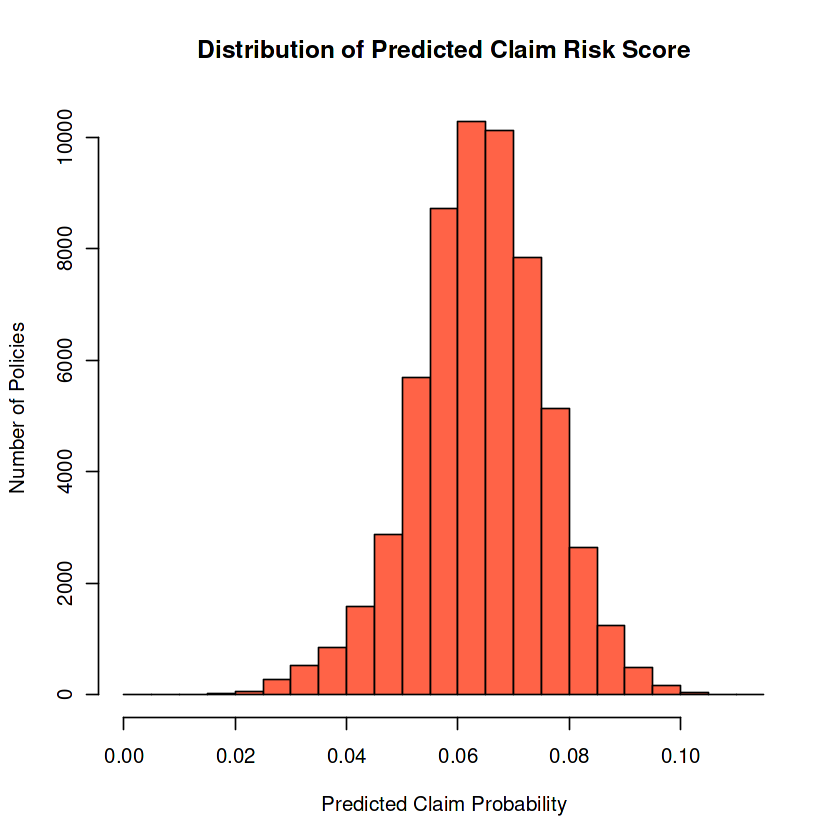

In [16]:
insurance_claim$risk_score <- predict(claim_glm_extended, type = "response")

summary(insurance_claim$risk_score)

# Rank vehicle segments by average predicted risk
segment_risk <- sort(tapply(insurance_claim$risk_score, insurance_claim$segment, mean), decreasing = TRUE)
segment_risk

hist(insurance_claim$risk_score, col = "tomato", breaks = 30,
     main = "Distribution of Predicted Claim Risk Score",
     xlab = "Predicted Claim Probability", ylab = "Number of Policies")

## 16. Vehicle Size & Weight vs Claim Risk
Insurers rate on vehicle dimensions and weight as a proxy for repair cost and accident severity. Testing whether claimants' vehicles differ systematically in size from non-claimants'.


	Welch Two Sample t-test

data:  gross_weight by is_claim
t = -0.95044, df = 4285.6, p-value = 0.3419
alternative hypothesis: true difference in means between group No Claim and group Claim is not equal to 0
95 percent confidence interval:
 -10.354369   3.592872
sample estimates:
mean in group No Claim    mean in group Claim 
              1385.061               1388.441 



	F test to compare two variances

data:  gross_weight by is_claim
F = 1.019, num df = 54843, denom df = 3747, p-value = 0.4353
alternative hypothesis: true ratio of variances is not equal to 1
95 percent confidence interval:
 0.9719566 1.0673441
sample estimates:
ratio of variances 
          1.019028 



	Pearson's product-moment correlation

data:  insurance_claim$length and insurance_claim$width
t = 552.37, df = 58590, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9146043 0.9172132
sample estimates:
      cor 
0.9159184 


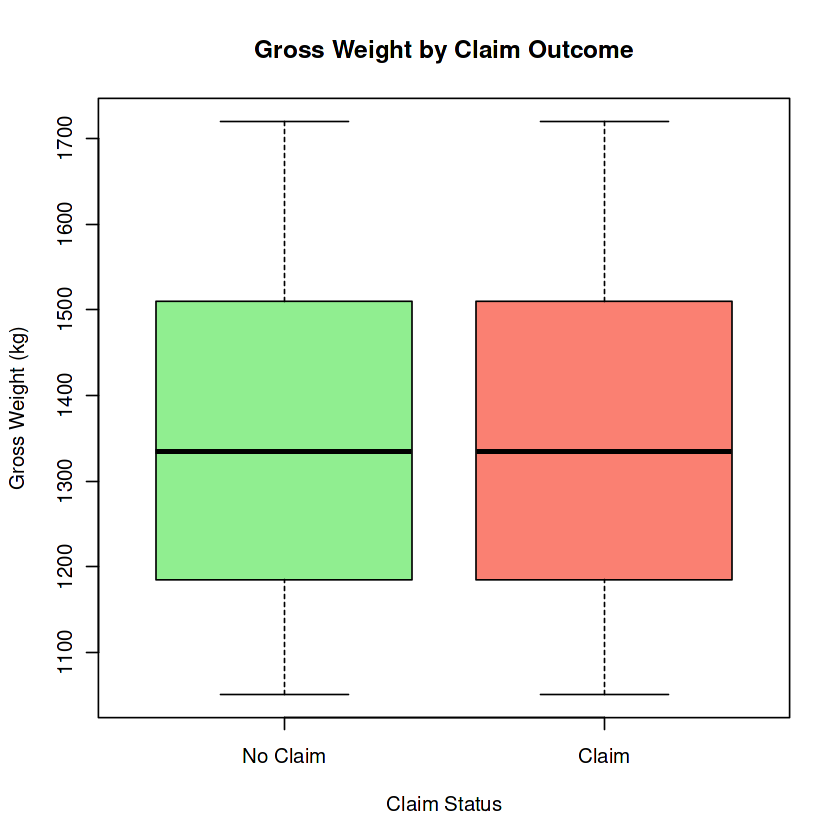

In [17]:
t.test(gross_weight ~ is_claim, data = insurance_claim)
var.test(gross_weight ~ is_claim, data = insurance_claim)

cor.test(insurance_claim$length, insurance_claim$width)

boxplot(gross_weight ~ is_claim, data = insurance_claim, col = c("lightgreen","salmon"),
        main = "Gross Weight by Claim Outcome", xlab = "Claim Status", ylab = "Gross Weight (kg)")

## 17. Engine Size Risk Analysis
Displacement and cylinder count are standard motor-insurance rating factors — larger engines are typically priced higher. Testing their relationship with claim occurrence.

                    Df    Sum Sq   Mean Sq F value Pr(>F)    
factor(cylinder)     1 3.118e+09 3.118e+09  176104 <2e-16 ***
Residuals        58590 1.037e+09 1.770e+04                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

   
      No Claim      Claim
  3 0.94029373 0.05970627
  4 0.93349667 0.06650333

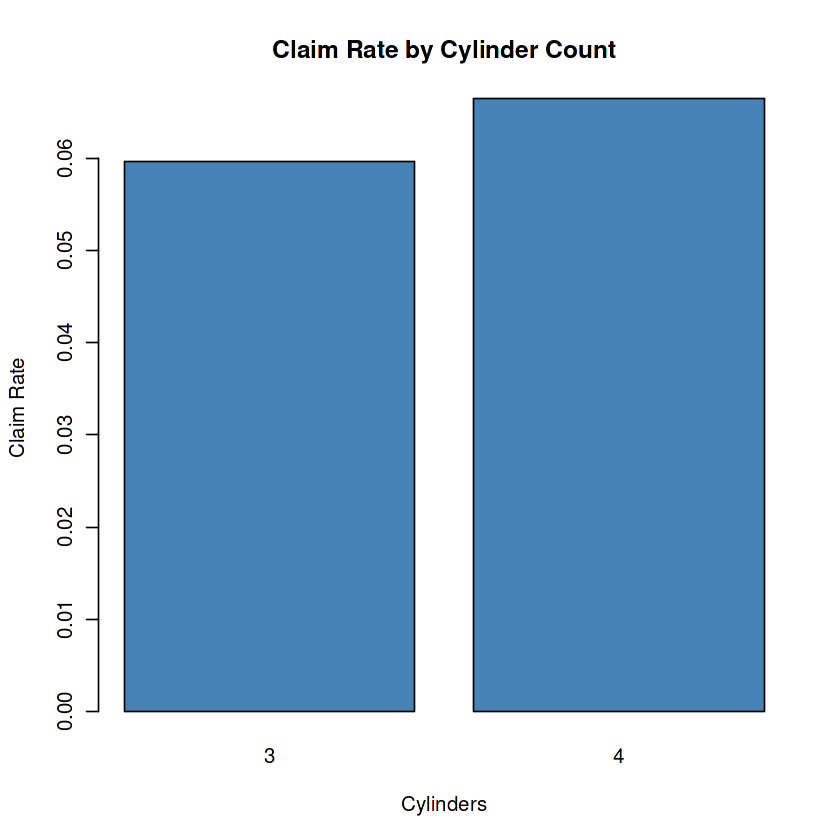

In [18]:
displacement_aov <- aov(displacement ~ factor(cylinder), data = insurance_claim)
summary(displacement_aov)

cylinder_claim_table <- table(insurance_claim$cylinder, insurance_claim$is_claim)
prop.table(cylinder_claim_table, margin = 1)

barplot(prop.table(cylinder_claim_table, margin = 1)[, "Claim"],
        col = "steelblue", main = "Claim Rate by Cylinder Count",
        xlab = "Cylinders", ylab = "Claim Rate")

## 18. Safety Equipment Index
Insurers give No-Claims/safety discounts based on fitted safety equipment. Building a composite safety score from multiple binary features and testing its relationship with claims.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00    3.00    4.00    5.59   10.00   11.00 


	Pearson's product-moment correlation

data:  insurance_claim$safety_index and as.numeric(insurance_claim$is_claim) - 1
t = 0.9572, df = 58590, p-value = 0.3385
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.004142786  0.012051200
sample estimates:
        cor 
0.003954466 



	Welch Two Sample t-test

data:  safety_index by is_claim
t = -0.95734, df = 4275.5, p-value = 0.3384
alternative hypothesis: true difference in means between group No Claim and group Claim is not equal to 0
95 percent confidence interval:
 -0.16759802  0.05762104
sample estimates:
mean in group No Claim    mean in group Claim 
              5.586153               5.641142 


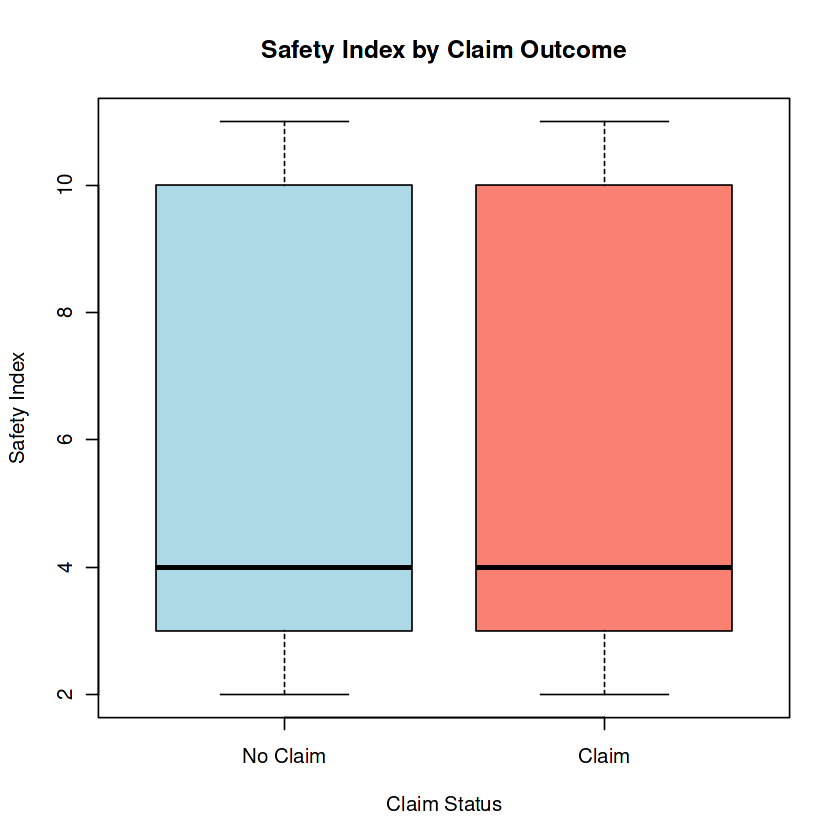

In [19]:
safety_cols <- c("is_esc","is_brake_assist","is_parking_sensors","is_parking_camera","is_tpms")
safety_binary <- sapply(insurance_claim[safety_cols], function(x) as.numeric(x == "Yes"))

insurance_claim$safety_index <- rowSums(safety_binary) + insurance_claim$airbags

summary(insurance_claim$safety_index)
cor.test(insurance_claim$safety_index, as.numeric(insurance_claim$is_claim) - 1)
t.test(safety_index ~ is_claim, data = insurance_claim)

boxplot(safety_index ~ is_claim, data = insurance_claim, col = c("lightblue","salmon"),
        main = "Safety Index by Claim Outcome", xlab = "Claim Status", ylab = "Safety Index")

## 19. Braking System Analysis
Testing whether brake type (Disc vs Drum) is associated with claim occurrence — a factor tied to stopping distance and accident risk.

      
       No Claim Claim
  Disc    13117   901
  Drum    41727  2847


	Pearson's Chi-squared test with Yates' continuity correction

data:  brake_table
X-squared = 0.022611, df = 1, p-value = 0.8805


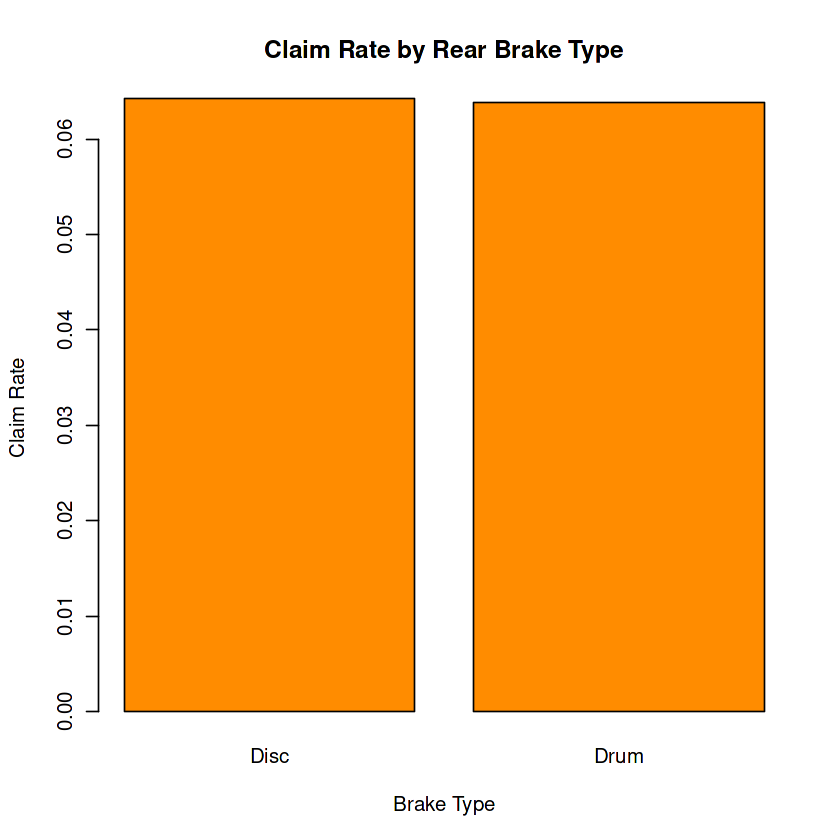

In [20]:
brake_table <- table(insurance_claim$rear_brakes_type, insurance_claim$is_claim)
brake_table
chisq.test(brake_table)

barplot(prop.table(brake_table, margin = 1)[, "Claim"],
        col = "darkorange", main = "Claim Rate by Rear Brake Type",
        xlab = "Brake Type", ylab = "Claim Rate")

## 20. Actuarial Age Banding
Insurers don't rate on raw age — they bucket policyholders into risk bands (e.g. young/standard/senior). Recreating that bucketing and testing claim rate differences across bands.

                   
                      No Claim      Claim
  Band 1 (Youngest) 0.94455028 0.05544972
  Band 2            0.93638171 0.06361829
  Band 3            0.93169819 0.06830181
  Band 4 (Oldest)   0.93129109 0.06870891


	Pearson's Chi-squared test

data:  age_band_table
X-squared = 27.732, df = 3, p-value = 4.134e-06



Call:
glm(formula = is_claim ~ age_band_ordered, family = binomial, 
    data = insurance_claim)

Coefficients:
                     Estimate Std. Error  z value Pr(>|z|)    
(Intercept)        -2.686e+00  1.694e-02 -158.574  < 2e-16 ***
age_band_ordered.L  1.703e-01  3.465e-02    4.915 8.88e-07 ***
age_band_ordered.Q -6.987e-02  3.388e-02   -2.062   0.0392 *  
age_band_ordered.C  8.733e-05  3.308e-02    0.003   0.9979    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 27860  on 58591  degrees of freedom
Residual deviance: 27832  on 58588  degrees of freedom
AIC: 27840

Number of Fisher Scoring iterations: 5


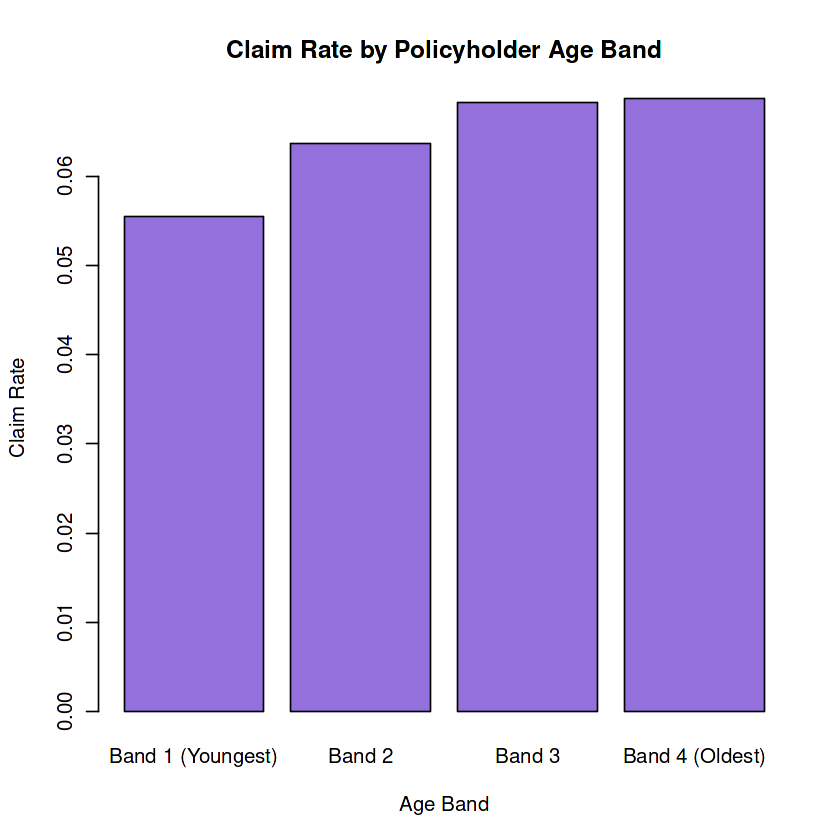

In [21]:
insurance_claim$age_band <- cut(insurance_claim$age_of_policyholder,
                                  breaks = quantile(insurance_claim$age_of_policyholder, probs = seq(0, 1, 0.25)),
                                  labels = c("Band 1 (Youngest)","Band 2","Band 3","Band 4 (Oldest)"),
                                  include.lowest = TRUE)

age_band_table <- table(insurance_claim$age_band, insurance_claim$is_claim)
prop.table(age_band_table, margin = 1)
chisq.test(age_band_table)

# Test for a linear trend in risk across the ordered age bands
insurance_claim$age_band_ordered <- factor(insurance_claim$age_band, ordered = TRUE)
trend_glm <- glm(is_claim ~ age_band_ordered, data = insurance_claim, family = binomial)
summary(trend_glm)

barplot(prop.table(age_band_table, margin = 1)[, "Claim"],
        col = "mediumpurple", main = "Claim Rate by Policyholder Age Band",
        xlab = "Age Band", ylab = "Claim Rate")

## 21. Final Multivariate Pricing-Style GLM
Bringing the validated rating factors together into one model — age band, vehicle segment, safety index, engine size, and area density — mirroring how a real motor pricing model is built.


Call:
glm(formula = is_claim ~ age_band + segment + safety_index + 
    displacement + population_density, family = binomial, data = insurance_claim)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -2.743e+00  2.241e-01 -12.238  < 2e-16 ***
age_bandBand 2           1.491e-01  4.915e-02   3.033  0.00242 ** 
age_bandBand 3           2.240e-01  4.854e-02   4.614 3.94e-06 ***
age_bandBand 4 (Oldest)  2.286e-01  4.952e-02   4.617 3.90e-06 ***
segmentB1               -5.889e-03  8.523e-02  -0.069  0.94492    
segmentB2                1.599e-01  1.165e-01   1.372  0.16998    
segmentC1                1.201e-01  1.631e-01   0.737  0.46128    
segmentC2                1.181e-01  2.243e-01   0.527  0.59842    
segmentUtility           3.790e-02  1.538e-01   0.246  0.80530    
safety_index            -8.009e-04  1.327e-02  -0.060  0.95186    
displacement            -8.513e-05  2.475e-04  -0.344  0.73088    
population_density      -4.231

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,58588,27831.98,NA,NA,NA
2,58580,27801.77,8,30.20847,0.0001941704


,df,AIC
,<dbl>,<dbl>
claim_glm,6,27761.19
claim_glm_extended,11,27742.47
final_glm,12,27825.77


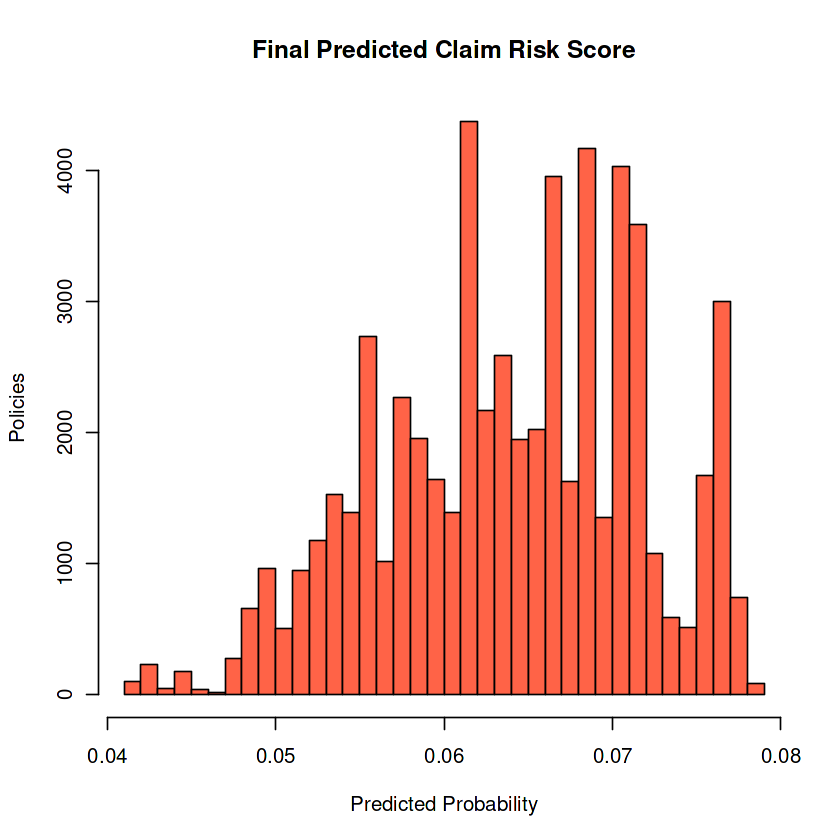

In [22]:
final_glm <- glm(is_claim ~ age_band + segment + safety_index + displacement +
                    population_density,
                  data = insurance_claim, family = binomial)
summary(final_glm)

# Test whether the extra rating factors significantly improve on a simple age-only baseline
baseline_glm <- glm(is_claim ~ age_band, data = insurance_claim, family = binomial)
anova(baseline_glm, final_glm, test = "Chisq")

AIC(claim_glm, claim_glm_extended, final_glm)

insurance_claim$final_risk_score <- predict(final_glm, type = "response")
hist(insurance_claim$final_risk_score, col = "tomato", breaks = 30,
     main = "Final Predicted Claim Risk Score", xlab = "Predicted Probability", ylab = "Policies")

## Conclusion & Key Findings

**Overall claim rate** across the portfolio was **[X]%**, forming the collective mean used in the credibility analysis.

**[Age/vehicle age/etc.]** showed a statistically significant difference between claimants and non-claimants (t-test, p = [X]).

**GLM (logistic regression)** identified **[X]** as the strongest predictor(s) of claim occurrence (p = [X]).

**Population density** at the cluster level showed a **[positive/negative/weak/strong]** relationship with claim rate (r = [X], p = [X]).

**Credibility theory (EBCT)** shrank raw segment claim rates toward the portfolio mean, giving more stable estimates for lower-volume segments — directly mirroring how experience rating is used in practice.

**Chi-square tests** showed [fuel type/transmission type] was/was not significantly associated with claim occurrence (p = [X]).

**Confidence intervals** placed the overall claim rate at [X]% ± [X]%, and the ESC-vs-non-ESC comparison showed [a significant / no significant] difference.

**The extended GLM with interaction terms** [did/did not] significantly improve on the base model (deviance test, p = [X]), and had a lower/higher AIC ([X] vs [X]).

**The composite risk score** identified **[segment]** as the highest-risk vehicle segment on average.

---
**Knowledge Level:** CS1 (Actuarial Statistics)
**Next Steps:** CS2 — advanced GLMs, and CM1/CM2 for pricing and reserving applications